# Visual Breed Prediction – esempi su immagini

Questo notebook introduce una componente di **Computer Vision** nel progetto.

L'obiettivo è usare un modello pre-addestrato su ImageNet, in particolare **ResNet50**, per stimare le razze canine visivamente più probabili a partire dalle immagini dei cani.

Questa parte viene usata solo come **stima visiva**: il modello non identifica con certezza la razza reale del cane, ma propone le razze più simili in base all'aspetto dell'immagine.

In questo notebook vengono mostrati alcuni esempi su cani `Mixed Breed`, visualizzando:

- immagine del cane;
- top 5 classi predette dal modello;
- top 3 predizioni limitate alle sole classi canine.


## 1. Import delle librerie

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

import torch
from torchvision.models import resnet50, ResNet50_Weights
from PIL import Image

from IPython.display import display
from tqdm import tqdm

## 2. Caricamento dataset e immagini

Viene caricato il dataset pulito dei cani e viene controllata la presenza della cartella `train_images`.

Le immagini del dataset PetFinder hanno nomi del tipo:

```text
PetID-numeroFoto.jpg
```

Esempio:

```text
3422e4906-1.jpg
```


In [2]:
dogs = pd.read_csv("../data/processed/dogs_clean.csv")

images_dir = Path("../data/raw/train_images")

print("Dataset:", dogs.shape)
print("Cartella immagini esiste:", images_dir.exists())

mixed_dogs = dogs[dogs["breed1_label"] == "Mixed Breed"].copy()

print("Numero cani Mixed Breed:", len(mixed_dogs))

mixed_dogs[["PetID", "Name", "breed1_label", "PhotoAmt"]].head()

Dataset: (8132, 32)
Cartella immagini esiste: True
Numero cani Mixed Breed: 5923


,PetID,Name,breed1_label,PhotoAmt
0,3422e4906,Brisco,Mixed Breed,7.0
1,5842f1ff5,Miko,Mixed Breed,8.0
2,850a43f90,Hunter,Mixed Breed,3.0
3,97aa9eeac,Siu Pak & Her 6 Puppies,Mixed Breed,9.0
4,8b693ca84,Bear,Mixed Breed,7.0


## 3. Caricamento modello ResNet50

Viene usata una ResNet50 pre-addestrata su ImageNet.

ImageNet contiene molte classi di razze canine, quindi il modello può essere usato per ottenere una stima visiva della razza.


In [3]:
weights = ResNet50_Weights.DEFAULT

model = resnet50(weights=weights)
model.eval()

preprocess = weights.transforms()
categories = weights.meta["categories"]

print("Numero classi ImageNet:", len(categories))
print(categories[:20])

Numero classi ImageNet: 1000
['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead', 'electric ray', 'stingray', 'cock', 'hen', 'ostrich', 'brambling', 'goldfinch', 'house finch', 'junco', 'indigo bunting', 'robin', 'bulbul', 'jay', 'magpie', 'chickadee']


## 4. Selezione delle classi canine

ImageNet contiene 1000 classi, ma non tutte sono razze canine.

Per evitare risultati non pertinenti, viene creata una lista di classi canine filtrando i nomi delle categorie.


In [4]:
dog_keywords = [
    "terrier",
    "retriever",
    "spaniel",
    "shepherd",
    "hound",
    "poodle",
    "husky",
    "beagle",
    "chihuahua",
    "doberman",
    "rottweiler",
    "collie",
    "corgi",
    "bulldog",
    "mastiff",
    "pinscher",
    "setter",
    "dane",
    "wolfhound",
    "malamute",
    "samoyed",
    "schipperke",
    "affenpinscher"
]

dog_class_indices = [
    i for i, cls in enumerate(categories)
    if any(word in cls.lower() for word in dog_keywords)
]

dog_classes = [categories[i] for i in dog_class_indices]

print("Numero classi canine trovate:", len(dog_classes))
dog_classes

Numero classi canine trovate: 65


['Chihuahua',
 'Japanese spaniel',
 'Blenheim spaniel',
 'toy terrier',
 'Afghan hound',
 'beagle',
 'bloodhound',
 'black-and-tan coonhound',
 'Walker hound',
 'English foxhound',
 'Irish wolfhound',
 'Italian greyhound',
 'Ibizan hound',
 'Norwegian elkhound',
 'otterhound',
 'Scottish deerhound',
 'Staffordshire bullterrier',
 'American Staffordshire terrier',
 'Bedlington terrier',
 'Border terrier',
 'Kerry blue terrier',
 'Irish terrier',
 'Norfolk terrier',
 'Norwich terrier',
 'Yorkshire terrier',
 'wire-haired fox terrier',
 'Lakeland terrier',
 'Sealyham terrier',
 'Australian terrier',
 'Scotch terrier',
 'Tibetan terrier',
 'silky terrier',
 'soft-coated wheaten terrier',
 'West Highland white terrier',
 'flat-coated retriever',
 'curly-coated retriever',
 'golden retriever',
 'Labrador retriever',
 'Chesapeake Bay retriever',
 'English setter',
 'Irish setter',
 'Gordon setter',
 'Brittany spaniel',
 'Welsh springer spaniel',
 'cocker spaniel',
 'Sussex spaniel',
 'Irish w

## 5. Funzioni di predizione

La funzione `predict_image_classes` restituisce:

- top 5 classi generali di ImageNet;
- top 3 classi canine, ignorando le classi non relative ai cani.


In [5]:
def predict_image_classes(image_path, top_general=5, top_dogs=3):
    image = Image.open(image_path).convert("RGB")
    input_tensor = preprocess(image).unsqueeze(0)

    with torch.no_grad():
        outputs = model(input_tensor)

    probabilities = torch.nn.functional.softmax(outputs[0], dim=0)

    general_prob, general_catid = torch.topk(probabilities, top_general)

    general_predictions = [
        {
            "class": categories[catid],
            "score": prob.item()
        }
        for prob, catid in zip(general_prob, general_catid)
    ]

    dog_probs = probabilities[dog_class_indices]
    top_dog_prob, top_dog_pos = torch.topk(dog_probs, top_dogs)

    dog_predictions = []

    for prob, pos in zip(top_dog_prob, top_dog_pos):
        original_index = dog_class_indices[pos]
        dog_predictions.append({
            "class": categories[original_index],
            "score": prob.item()
        })

    return image, general_predictions, dog_predictions

## 6. Funzione per mostrare un esempio

Questa funzione visualizza l'immagine e stampa le predizioni del modello.


In [6]:
def show_prediction_example(pet_id, image_number=1):
    image_path = images_dir / f"{pet_id}-{image_number}.jpg"

    if not image_path.exists():
        print("Immagine non trovata:", image_path)
        return

    row = dogs[dogs["PetID"] == pet_id].iloc[0]

    print("PetID:", pet_id)
    print("Nome:", row["Name"])
    print("Razza originale:", row["breed1_label"], "/", row["breed2_label"])
    print("File immagine:", image_path.name)
    print()

    image, general_predictions, dog_predictions = predict_image_classes(image_path)

    display(image)

    print("\nTOP 5 CLASSI GENERALI IMAGENET")
    for pred in general_predictions:
        print(f'{pred["class"]} - {pred["score"] * 100:.2f}%')

    print("\nTOP 3 RAZZE CANINE VISIVE")
    for pred in dog_predictions:
        print(f'{pred["class"]} - {pred["score"] * 100:.2f}%')

## 7. Esempio 1 – Brisco

PetID: 3422e4906
Nome: Brisco
Razza originale: Mixed Breed / nan
File immagine: 3422e4906-1.jpg



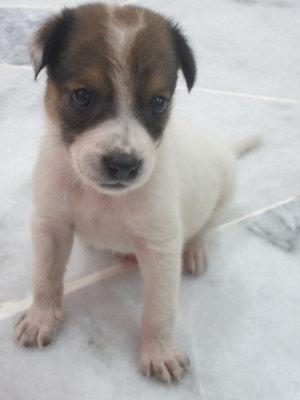


TOP 5 CLASSI GENERALI IMAGENET
toy terrier - 33.02%
wire-haired fox terrier - 11.67%
Chihuahua - 4.72%
Border terrier - 3.27%
American Staffordshire terrier - 1.79%

TOP 3 RAZZE CANINE VISIVE
toy terrier - 33.02%
wire-haired fox terrier - 11.67%
Chihuahua - 4.72%


In [13]:
show_prediction_example("3422e4906", image_number=1)

## 8. Esempio 2 – Miko

PetID: 5842f1ff5
Nome: Miko
Razza originale: Mixed Breed / nan
File immagine: 5842f1ff5-1.jpg



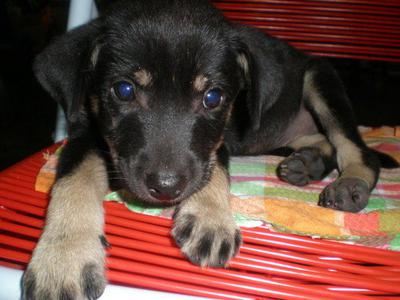


TOP 5 CLASSI GENERALI IMAGENET
Rottweiler - 12.71%
kelpie - 9.61%
black-and-tan coonhound - 5.35%
miniature pinscher - 3.80%
toy terrier - 2.84%

TOP 3 RAZZE CANINE VISIVE
Rottweiler - 12.71%
black-and-tan coonhound - 5.35%
miniature pinscher - 3.80%


In [17]:
show_prediction_example("5842f1ff5", image_number=1)

## 9. Esempio 3 – Hunter

PetID: 850a43f90
Nome: Hunter
Razza originale: Mixed Breed / nan
File immagine: 850a43f90-1.jpg



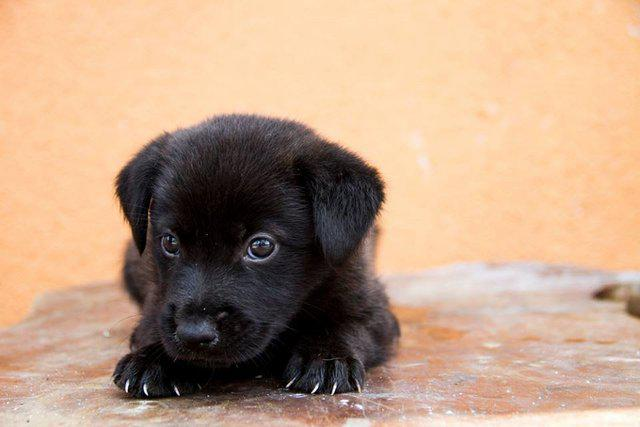


TOP 5 CLASSI GENERALI IMAGENET
groenendael - 17.96%
Newfoundland - 16.38%
Tibetan mastiff - 6.40%
flat-coated retriever - 3.76%
schipperke - 2.35%

TOP 3 RAZZE CANINE VISIVE
Tibetan mastiff - 6.40%
flat-coated retriever - 3.76%
schipperke - 2.35%


In [9]:
show_prediction_example("850a43f90", image_number=1)

## 10. Esempi automatici su altri Mixed Breed

La cella seguente seleziona automaticamente alcuni cani `Mixed Breed` con almeno una foto e mostra le predizioni visive.


In [10]:
example_petids = (
    mixed_dogs[mixed_dogs["PhotoAmt"] > 0]["PetID"]
    .drop_duplicates()
    .head(5)
    .tolist()
)

example_petids

['3422e4906', '5842f1ff5', '850a43f90', '97aa9eeac', '8b693ca84']

PetID: 3422e4906
Nome: Brisco
Razza originale: Mixed Breed / nan
File immagine: 3422e4906-1.jpg



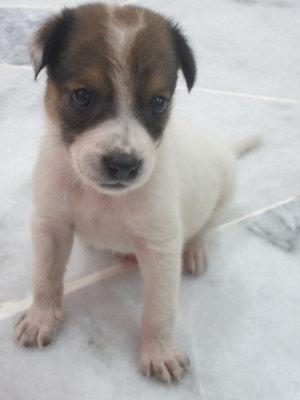


TOP 5 CLASSI GENERALI IMAGENET
toy terrier - 33.02%
wire-haired fox terrier - 11.67%
Chihuahua - 4.72%
Border terrier - 3.27%
American Staffordshire terrier - 1.79%

TOP 3 RAZZE CANINE VISIVE
toy terrier - 33.02%
wire-haired fox terrier - 11.67%
Chihuahua - 4.72%


PetID: 5842f1ff5
Nome: Miko
Razza originale: Mixed Breed / nan
File immagine: 5842f1ff5-1.jpg



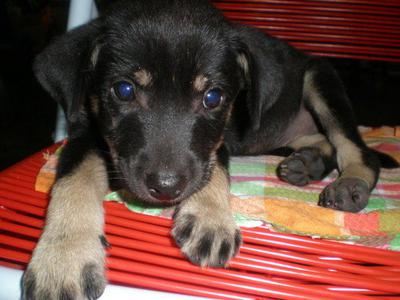


TOP 5 CLASSI GENERALI IMAGENET
Rottweiler - 12.71%
kelpie - 9.61%
black-and-tan coonhound - 5.35%
miniature pinscher - 3.80%
toy terrier - 2.84%

TOP 3 RAZZE CANINE VISIVE
Rottweiler - 12.71%
black-and-tan coonhound - 5.35%
miniature pinscher - 3.80%


PetID: 850a43f90
Nome: Hunter
Razza originale: Mixed Breed / nan
File immagine: 850a43f90-1.jpg



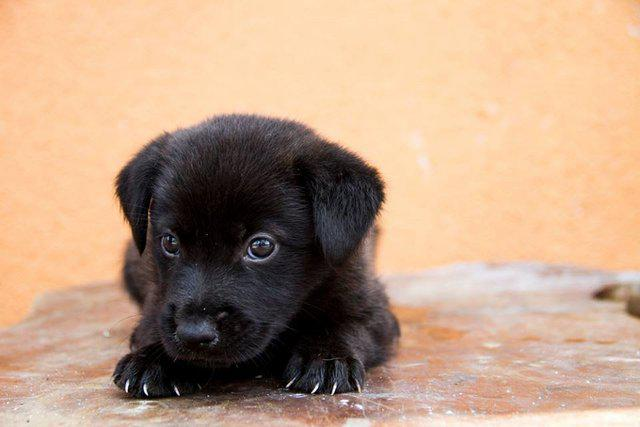


TOP 5 CLASSI GENERALI IMAGENET
groenendael - 17.96%
Newfoundland - 16.38%
Tibetan mastiff - 6.40%
flat-coated retriever - 3.76%
schipperke - 2.35%

TOP 3 RAZZE CANINE VISIVE
Tibetan mastiff - 6.40%
flat-coated retriever - 3.76%
schipperke - 2.35%


PetID: 97aa9eeac
Nome: Siu Pak & Her 6 Puppies
Razza originale: Mixed Breed / nan
File immagine: 97aa9eeac-1.jpg



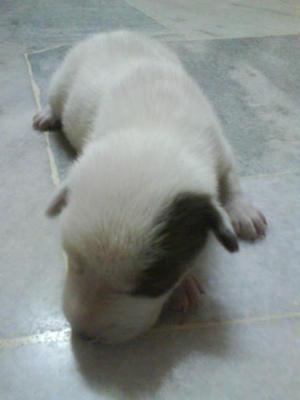


TOP 5 CLASSI GENERALI IMAGENET
badger - 10.88%
polecat - 5.45%
black-footed ferret - 4.53%
weasel - 2.47%
hog - 2.11%

TOP 3 RAZZE CANINE VISIVE
Chihuahua - 1.99%
Sealyham terrier - 0.77%
French bulldog - 0.69%


PetID: 8b693ca84
Nome: Bear
Razza originale: Mixed Breed / nan
File immagine: 8b693ca84-1.jpg



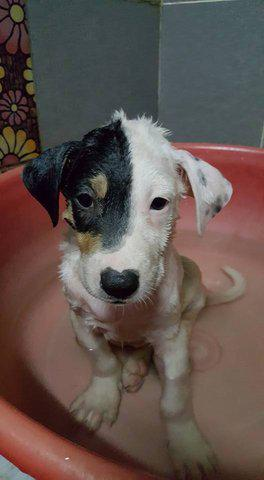


TOP 5 CLASSI GENERALI IMAGENET
toy terrier - 13.02%
wire-haired fox terrier - 7.87%
Italian greyhound - 6.49%
whippet - 3.96%
Sealyham terrier - 2.90%

TOP 3 RAZZE CANINE VISIVE
toy terrier - 13.02%
wire-haired fox terrier - 7.87%
Italian greyhound - 6.49%




In [11]:
for pet_id in example_petids:
    print("=" * 80)
    show_prediction_example(pet_id, image_number=1)
    print("\n")

## 11. Conclusioni

Il notebook mostra che è possibile usare un modello di Computer Vision pre-addestrato per ottenere una stima visiva delle razze più probabili per i cani indicati come `Mixed Breed`.

Questa informazione non deve essere interpretata come razza reale certa, ma come indicazione ausiliaria.

Nel prossimo notebook sarà possibile applicare questa procedura a tutti i cani `Mixed Breed` e salvare le predizioni in un file CSV con colonne come:

- `visual_breed_1`;
- `visual_breed_1_score`;
- `visual_breed_2`;
- `visual_breed_2_score`;
- `visual_breed_3`;
- `visual_breed_3_score`.

Queste informazioni potranno poi essere integrate nel sistema di matching cane–famiglia.
